In [145]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [146]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\species

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\species


In [147]:
def plot_confidence_ellipse(data, confidence_level=0.90):
    mean_x, mean_y = np.mean(data, axis=0)
    cov_matrix = np.cov(data, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(cov_matrix)

    if confidence_level == 0.95:
        chi_square_val = 5.991
    elif confidence_level == 0.90:
        chi_square_val = 4.605
    elif confidence_level == 0.80:
        chi_square_val = 3.219
    else:
        raise ValueError("confidence_level must be 0.80, 0.90, or 0.95")

    scale = np.sqrt(chi_square_val)
    width, height = 2 * scale * np.sqrt(eigvals)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    return (mean_x, mean_y), width, height, angle


def cal_ellipse(data, group_name, component1='PC1', componet2='PC2', cl=0.95):
    sub = data[data['Group'] == group_name].copy()
    sub = sub[[component1, componet2]].dropna().values

    if sub.shape[0] < 3:
        return None

    return plot_confidence_ellipse(sub, confidence_level=cl)

In [148]:
df = pd.read_csv('pcoa_bray_coordinates.csv')
var_df = pd.read_csv('pcoa_bray_variance.csv')
perma = pd.read_csv('permanova_bray.csv')
print(df.head())
print(var_df.head())
print(perma.head())

  SampleID       PC1       PC2    Group SamplingWeek      Subject_ID   ExpNo  \
0   C01-2w -0.465165 -0.143714  Control        Week2    Exp1_C1-2_2w    Exp1   
1   C02-2w -0.478254 -0.126691  Control        Week2    Exp1_C2-1_2w    Exp1   
2   C03-2w -0.465516 -0.149379  Control        Week2  Exp1-S_C1-1_2w  Exp1-S   
3   C09-2w -0.445968 -0.155590  Control        Week2  Exp1-S_C3-1_2w  Exp1-S   
4   C10-2w -0.466401 -0.157960  Control        Week2  Exp1-S_C3-2_2w  Exp1-S   

  MouseNo2 CageNo Age Sex  Initial_b.w   b.w   BM_wbc  Spleen  
0      C01     C1  9W   M         20.5  22.8  1960000    64.0  
1      C02     C2  9W   M         20.4  23.4   970000   136.0  
2      C03   C1-S  9W   M         20.6  22.8   568000    67.8  
3      C09   C3-S  9W   M         20.3  22.4  1280000    74.6  
4      C10   C3-S  9W   M         20.1  22.4   243000    59.3  
       PC1      PC2
0  47.4804  36.2011
        Method          F       R2  Pvalue   N
0  Bray-Curtis  11.092825  0.46042   0.001  15


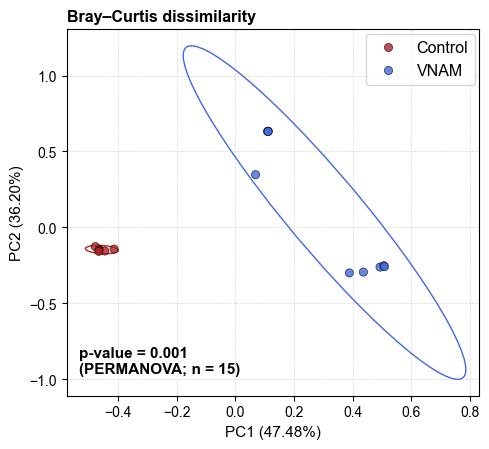

In [149]:
palette = ['firebrick', 'royalblue']

marker_size = 35
ellipse_cl = 0.95


fig, ax = plt.subplots(figsize=(5, 4.6))

orders = ['Control', 'VNAM']
df = df[df['Group'].isin(orders)].copy()

pc1 = float(var_df.loc[0, 'PC1'])
pc2 = float(var_df.loc[0, 'PC2'])
pval = float(perma.loc[0, 'Pvalue'])
nval = int(perma.loc[0, 'N'])


# ellipse 채우기
#for grp, color in zip(orders, palette):
#    out = cal_ellipse(df, group_name=grp, cl=ellipse_cl, component1='PC1', componet2='PC2')
#    if out is not None:
#        (mean_x, mean_y), width, height, angle = out
#        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor=color, facecolor=color, alpha=0.10)
#        ax.add_patch(ellipse)

# ellipse 외곽선
for grp, color in zip(orders, palette):
    out = cal_ellipse(df, group_name=grp, cl=ellipse_cl, component1='PC1', componet2='PC2')
    if out is not None:
        (mean_x, mean_y), width, height, angle = out
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor=color, facecolor='none', alpha=1, linestyle='-')  #Edit: or alpha=0.35, linestyle='--'
        ax.add_patch(ellipse)

sns.scatterplot(data=df, x='PC1', y='PC2', hue='Group', hue_order=orders, palette=list(palette), s=marker_size, alpha=0.8, edgecolor='k', ax=ax)

plt.title('Bray–Curtis dissimilarity', loc='left', fontsize=11.5, fontweight='bold')
plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
legend1 = plt.legend(loc='upper right', bbox_to_anchor=(1.01, 1.01), fontsize=11.5)  # 그룹명에 대한 legend / ## Edit: bbox_to_anchor=(1.01, 1.01) or (0.31, 0.99)
label = f'p-value = {pval:.3g}\n(PERMANOVA; n = {nval})'
legend2 = plt.legend([], [], title=label, loc='lower left', frameon=False, title_fontsize=11)  # p-value에 대한 legend
legend2.get_title().set_fontweight('bold')
fig.add_artist(legend1)

plt.tight_layout()
plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.savefig('bray.png', dpi=500, bbox_inches='tight')

In [150]:
df = pd.read_csv('pcoa_jaccard_coordinates.csv')
var_df = pd.read_csv('pcoa_jaccard_variance.csv')
perma = pd.read_csv('permanova_jaccard.csv')
print(df.head())
print(var_df.head())
print(perma.head())

  SampleID       PC1       PC2    Group SamplingWeek      Subject_ID   ExpNo  \
0   C01-2w -0.512299 -0.024104  Control        Week2    Exp1_C1-2_2w    Exp1   
1   C02-2w -0.511503 -0.023313  Control        Week2    Exp1_C2-1_2w    Exp1   
2   C03-2w -0.519202 -0.025007  Control        Week2  Exp1-S_C1-1_2w  Exp1-S   
3   C09-2w -0.487517 -0.019087  Control        Week2  Exp1-S_C3-1_2w  Exp1-S   
4   C10-2w -0.517113 -0.025239  Control        Week2  Exp1-S_C3-2_2w  Exp1-S   

  MouseNo2 CageNo Age Sex  Initial_b.w   b.w   BM_wbc  Spleen  
0      C01     C1  9W   M         20.5  22.8  1960000    64.0  
1      C02     C2  9W   M         20.4  23.4   970000   136.0  
2      C03   C1-S  9W   M         20.6  22.8   568000    67.8  
3      C09   C3-S  9W   M         20.3  22.4  1280000    74.6  
4      C10   C3-S  9W   M         20.1  22.4   243000    59.3  
       PC1     PC2
0  54.3551  24.549
    Method          F        R2  Pvalue   N
0  Jaccard  15.338454  0.541259   0.001  15


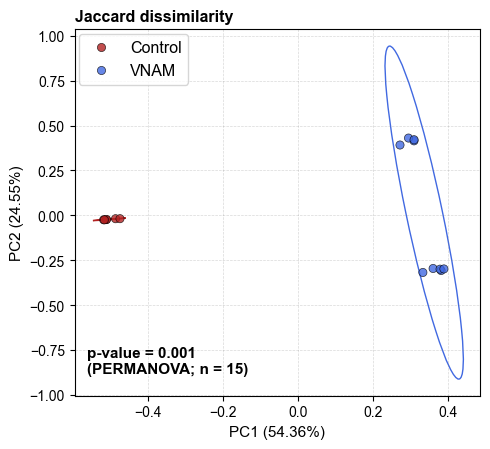

In [151]:
palette = ['firebrick', 'royalblue']

marker_size = 35
ellipse_cl = 0.95


fig, ax = plt.subplots(figsize=(5, 4.6))

orders = ['Control', 'VNAM']
df = df[df['Group'].isin(orders)].copy()

pc1 = float(var_df.loc[0, 'PC1'])
pc2 = float(var_df.loc[0, 'PC2'])
pval = float(perma.loc[0, 'Pvalue'])
nval = int(perma.loc[0, 'N'])


# ellipse 채우기
#for grp, color in zip(orders, palette):
#    out = cal_ellipse(df, group_name=grp, cl=ellipse_cl, component1='PC1', componet2='PC2')
#    if out is not None:
#        (mean_x, mean_y), width, height, angle = out
#        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor=color, facecolor=color, alpha=0.10)
#        ax.add_patch(ellipse)

# ellipse 외곽선
for grp, color in zip(orders, palette):
    out = cal_ellipse(df, group_name=grp, cl=ellipse_cl, component1='PC1', componet2='PC2')
    if out is not None:
        (mean_x, mean_y), width, height, angle = out
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor=color, facecolor='none', alpha=1, linestyle='-')  #Edit: or alpha=0.35, linestyle='--'
        ax.add_patch(ellipse)

sns.scatterplot(data=df, x='PC1', y='PC2', hue='Group', hue_order=orders, palette=list(palette), s=marker_size, alpha=0.8, edgecolor='k', ax=ax)

plt.title('Jaccard dissimilarity', loc='left', fontsize=11.5, fontweight='bold')
plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
legend1 = plt.legend(loc='upper right', bbox_to_anchor=(0.30, 1.01), fontsize=11.5)  # 그룹명에 대한 legend / ## Edit: bbox_to_anchor=(1.01, 1.01) or (0.31, 0.99)
label = f'p-value = {pval:.3g}\n(PERMANOVA; n = {nval})'
legend2 = plt.legend([], [], title=label, loc='lower left', frameon=False, title_fontsize=11)  # p-value에 대한 legend
legend2.get_title().set_fontweight('bold')
fig.add_artist(legend1)

plt.tight_layout()
plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.savefig('jaccard.png', dpi=500, bbox_inches='tight')